# Data loadings and preparations

> Fill in a module description here


In [ ]:
#| default_exp data.__init__

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import importlib
from dataclasses import dataclass
from typing import Dict
from omegaconf import OmegaConf

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributed as dist

from fastcore.utils import *
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import *

from fedai.data.vision import VisionBlock


In [ ]:
#| export

@dataclass(frozen=True)
class DatasetConfig:
    x: str
    y: str
    num_labels: int
    mean: tuple = (0.5, 0.5, 0.5)
    std: tuple = (0.5, 0.5, 0.5)
    size: int = 32

IMG_DATA_CONFIGS: Dict[str, DatasetConfig] = {
    
    "mnist": DatasetConfig(x= "image",
                           y= "label",
                           num_labels= 10, 
                           mean= (0.1307,),
                           std=(0.3081,),
                           size= 28),


    "cifar10": DatasetConfig(x= "img",
                             y= "label",
                             num_labels= 10,
                             mean= (0.4914, 0.4822, 0.4465),
                             std= (0.2023, 0.1994, 0.2010),
                             size= 32),


    "cifar100": DatasetConfig(x= "img",
                              y= "coarse_label",
                              num_labels=20,
                              mean= (0.4914, 0.4822, 0.4465),
                              std= (0.2470, 0.2435, 0.2616),
                              size= 32),


    "femnist": DatasetConfig(x= "image",
                             y= "label",
                             num_labels= 62,
                             mean= (0.1307,),
                             std=(0.3081,),
                             size= 28),


    "tiny-imagenet": DatasetConfig(x= "image",
                                   y= "label",
                                   num_labels= 200,
                                   mean= (0.485, 0.456, 0.406),
                                   std= (0.229, 0.224, 0.225),
                                   size= 64),

    
    "mnist_rotated_batched_40": DatasetConfig(x= "image",
                                              y= "label",
                                              num_labels= 10,
                                              mean= (0.1307,),
                                              std=(0.3081,),
                                              size= 28
                                              ),


}


In [ ]:
#| export
Img_data_dict= {
    "mnist": "ylecun/mnist",
    "mnist_rotated_batched_40": "ylecun/mnist",
    "cifar10": "uoft-cs/cifar10",
    "cifar100": "uoft-cs/cifar100",
    "femnist": "flwrlabs/femnist",
    "tiny-imagenet": "zh-plus/tiny-imagenet",
}

def init_data(cfg):
    if cfg.data.name in Img_data_dict:
        if cfg.data.name != "mnist_rotated_batched_40":
            partitioner_cls = getattr(importlib.import_module("flwr_datasets.partitioner"), cfg.data.partitioner.name)
        else: 
            partitioner_cls = getattr(importlib.import_module("fedai.data.vision.partitioners"), cfg.data.partitioner.name)
            
        partitioner = partitioner_cls(num_partitions= cfg.num_clients, **cfg.data.partitioner.kwargs)
        test_partitioner = partitioner_cls(num_partitions= cfg.num_clients, **cfg.data.partitioner.kwargs)
        
        fds = FederatedDataset(dataset= Img_data_dict[cfg.data.name], partitioners= {"train": partitioner, "test": test_partitioner})
        
        return fds

In [ ]:
#| export
def get_block(cfg, client_id, fds= None, train=True):

    if cfg.data.modality == ['Vision']:
        return VisionBlock(cfg, client_id, IMG_DATA_CONFIGS, train= train, fds= fds)

In [ ]:
#| hide
cfg = OmegaConf.load('./examples/cfg.yaml')
cfg.lr = 0.005
cfg.local_epochs = 5
cfg.tau = 0.1
cfg.batch_size = 32
# cfg.data.name = "cifar10"
cfg.data.name = "mnist_rotated_batched_40"

cfg.data.alpha = 0.5

cfg.data.partitioner = {}
# cfg.data.partitioner.name = "DirichletPartitioner"
cfg.data.partitioner.name = "RotatedPatchedPartitioner"

# cfg.data.partitioner.kwargs = {"alpha": 0.1, "partition_by": IMG_DATA_CONFIGS[cfg.data.name].y}
cfg.data.partitioner.kwargs = {}

In [ ]:
cfg.num_clients

40

In [ ]:
#| hide
fds = init_data(cfg)

In [ ]:
#| hide
block = get_block(cfg, client_id= 30, fds= fds, train=True)

Partition 30: Cluster 4, Rot: 270°, Noise: 30.0%


torch.Size([1, 28, 28]) tensor(-0.4242) tensor(2.8215)
5


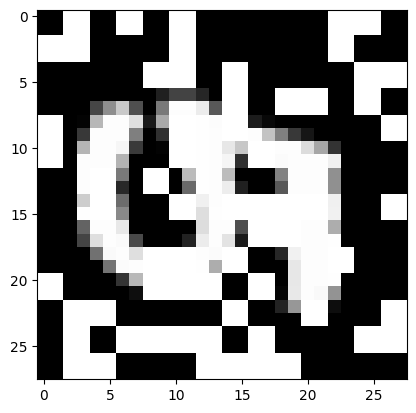

In [ ]:
#| hide
image, label = block[2]["image"], block[2]["label"]
print(image.shape, image.min(), image.max())
# denomralize = lambda x: x * torch.tensor(IMG_DATA_CONFIGS[cfg.data.name].std).view(-1, 1, 1) + torch.tensor(IMG_DATA_CONFIGS[cfg.data.name].mean).view(-1, 1, 1)
# image = denomralize(image)
plt.imshow(image.permute(1, 2, 0), cmap= "gray" if image.shape[0] == 1 else None)
print(label)
plt.show()

In [ ]:
#| export
def prepare_dl_dist(
        cfg,
        client_id,
        fds,
        train= True,
        collator=torch.utils.data.default_collate,
):
    block = get_block(cfg= cfg, client_id= client_id, fds= fds, train= train)

    dist_sampler = torch.utils.data.distributed.DistributedSampler(block)

    data_loader = torch.utils.data.DataLoader(
        block,
        collate_fn=collator,
        sampler=dist_sampler,
        batch_size=cfg.data.batch_size,
        drop_last=cfg.data.loader.drop_last,
        pin_memory=cfg.data.loader.pin_memory,
        num_workers=cfg.data.loader.num_workers,
        persistent_workers=(cfg.data.loader.num_workers > 0) and cfg.data.loader.persistent_workers,
    )


    return data_loader, dist_sampler

In [ ]:
#| export
def prepare_dl(cfg, client_id, fds, train=True, distributed=False):
    if distributed and torch.distributed.is_initialized():
        return prepare_dl_dist(cfg, client_id, fds, train)
    
    block = get_block(cfg, client_id, fds, train)
    dl = torch.utils.data.DataLoader(block, batch_size= cfg.data.batch_size, shuffle= True if train else False)
    return dl

In [ ]:
#| hide
dl = prepare_dl(cfg, client_id=30, fds= fds, train=True)
batch = next(iter(dl))
print(batch["image"].shape, batch["label"].shape)

Partition 30: Cluster 4, Rot: 270°, Noise: 30.0%
torch.Size([20, 1, 28, 28]) torch.Size([20])


In [ ]:
#| hide
dist.init_process_group(backend="gloo", init_method="tcp://localhost:12345", rank=0, world_size=1)
cfg.data.loader = {}
cfg.data.loader.pin_memory= False
cfg.data.loader.drop_last= False
cfg.data.loader.num_workers= 0
cfg.data.loader.persistent_workers= False
dist_dl, dist_sampler = prepare_dl(cfg, client_id=30, fds= fds, train=True, distributed=True)
dist.destroy_process_group()


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
Partition 30: Cluster 4, Rot: 270°, Noise: 30.0%


In [ ]:
#| hide
dist_sampler.set_epoch(0)
batch= next(iter(dist_dl))
print(batch["image"].shape, batch["label"].shape)

torch.Size([20, 1, 28, 28]) torch.Size([20])


In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()